In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Quantitative Inspection of the data

In [2]:
def visual_inspection(data_column):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(data_column, kde=True, color='skyblue', ax=axes[0])
    axes[0].set_title('Histogram & KDE (Distribution Shape)')

    sns.boxplot(x=data_column, color='lightgreen', ax=axes[1])
    axes[1].set_title('Box Plot (Identifying Outliers)')

    stats.probplot(data_column, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot (Normal Probability)')

# Qualitative Inspection of the data

In [3]:
def qualitative_report(df, column_name):
    data = df[column_name]
    
    mean = data.mean()
    median = data.median()
    skew = data.skew()
    kurt = data.kurtosis()
    
    print(f"\nSkewness: {skew:.2f}")
    if -0.5 < skew < 0.5:
        print("Interpretation: Fairly Symmetrical (Normal)")
    elif skew <= -0.5:
        print("Interpretation: Negatively Skewed (Left-tailed)")
    else:
        print("Interpretation: Positively Skewed (Right-tailed)")

    stat, p = stats.shapiro(data)
    print(f"\nShapiro-Wilk Test: p-value = {p:.4f}")
    if p > 0.05:
        print("Conclusion: Data likely follows a Normal Distribution.")
    else:
        print("Conclusion: Data does NOT follow a Normal Distribution.")

# Creating a Data Frame

In [4]:
np.random.seed(42)
normal_data = [('S'+str(i), np.random.randint(48, 53)) for i in range(1, 101)]

normal_data.append(('P_Out1', 100))
normal_data.append(('P_Out2', 100))
normal_data.append(('N_Out1', 0))

#df = pd.DataFrame(normal_data, columns=['s_id', 'test_score'])
df = pd.read_csv('placement.csv')

# Statistical analysis of the data

In [5]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


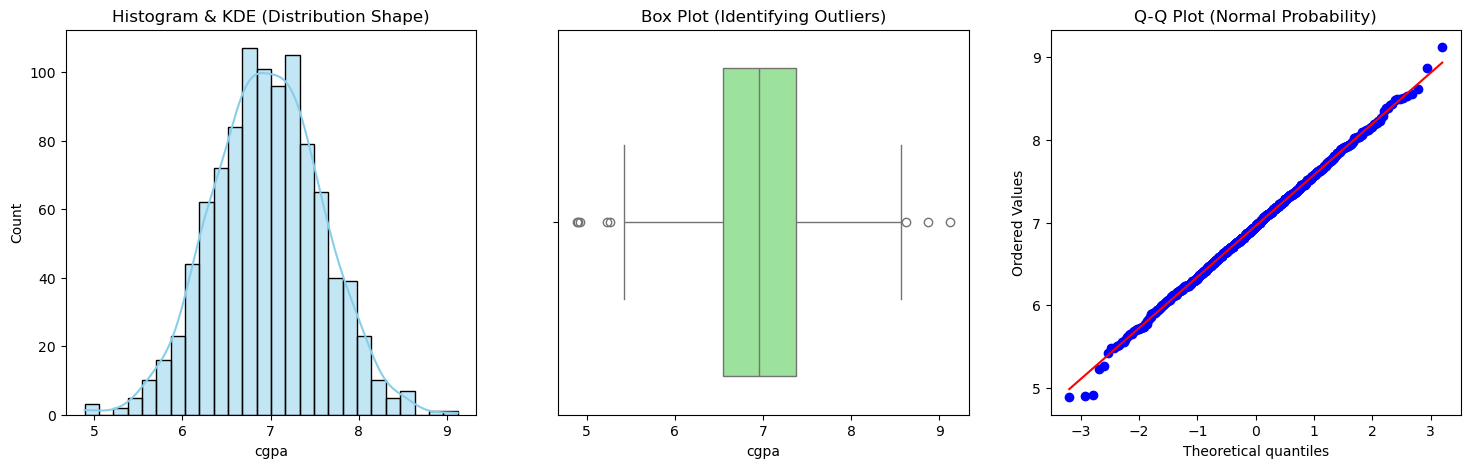

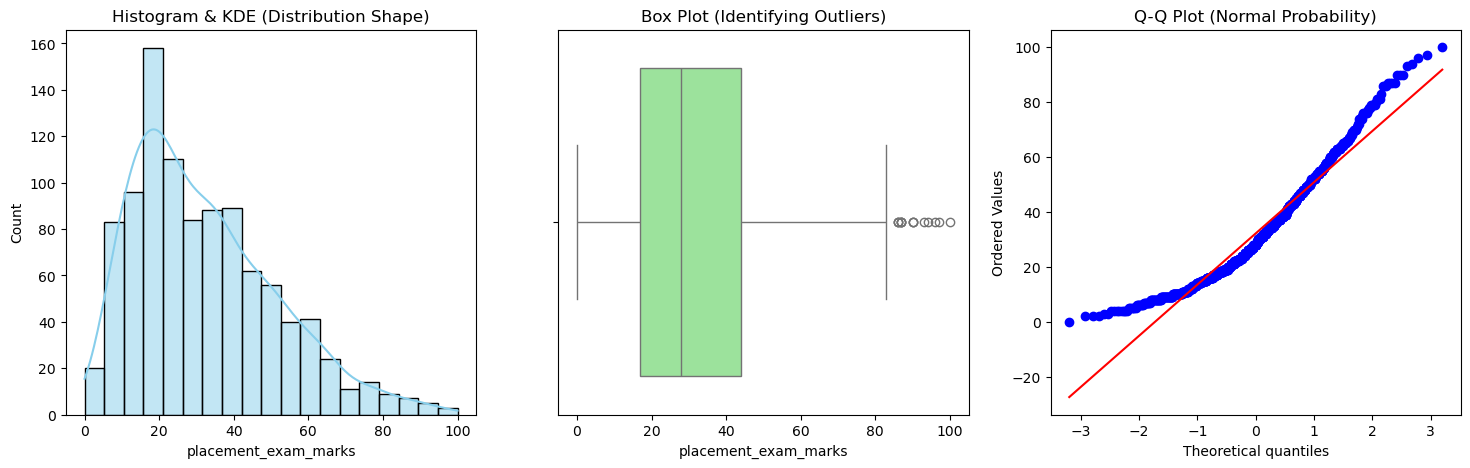

In [9]:
visual_inspection(df['cgpa'])
visual_inspection(df['placement_exam_marks'])

In [13]:
print("\n---cgpa---\n")
qualitative_report(df, 'cgpa')
print("\n---placement_exam_marks---\n")
qualitative_report(df, 'placement_exam_marks')


---cgpa---


Skewness: -0.01
Interpretation: Fairly Symmetrical (Normal)

Shapiro-Wilk Test: p-value = 0.9530
Conclusion: Data likely follows a Normal Distribution.

---placement_exam_marks---


Skewness: 0.84
Interpretation: Positively Skewed (Right-tailed)

Shapiro-Wilk Test: p-value = 0.0000
Conclusion: Data does NOT follow a Normal Distribution.


In [14]:
df['z_cgpa'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
#df['z_placement_exam_marks'] = (df['placement_exam_marks'] - df['placement_exam_marks'].mean())/df['placement_exam_marks'].std()
df

,cgpa,placement_exam_marks,placed,z_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [15]:
df[df['z_cgpa']>3]

,cgpa,placement_exam_marks,placed,z_cgpa
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [16]:
df[df['z_cgpa'] < -3]

,cgpa,placement_exam_marks,placed,z_cgpa
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [17]:
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)
IQR = Q3 - Q1

# Trimming the outliers from the dataset

In [18]:
df_trimmed = df[(df['z_cgpa'] > -3) & (df['z_cgpa'] < 3)]
df_trimmed

,cgpa,placement_exam_marks,placed,z_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping the outliers from the dataset

In [33]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(upper_limit)

outliers = df[(df['placement_exam_marks'] < lower_limit) | (df['placement_exam_marks'] > upper_limit)]
#outliers

df_trimmed_2 = df[(df['placement_exam_marks'] >= lower_limit) & (df['placement_exam_marks'] <= upper_limit)]
df_trimmed_2


84.5


,cgpa,placement_exam_marks,placed,z_cgpa,test_score_capped
0,7.19,26.0,1,0.371425,26.0
1,7.46,38.0,1,0.809810,38.0
2,7.54,40.0,1,0.939701,40.0
3,6.42,8.0,1,-0.878782,8.0
4,7.23,17.0,0,0.436371,17.0
...,...,...,...,...,...
995,8.87,44.0,1,3.099150,44.0
996,9.12,65.0,1,3.505062,65.0
997,4.89,34.0,0,-3.362960,34.0
998,8.62,46.0,1,2.693239,46.0


In [34]:
max_val = df_trimmed_2['placement_exam_marks'].max()

min_val = df_trimmed_2['placement_exam_marks'].min()

print(f"Max value: {max_val}")
print(f"Min value: {min_val}")

new_outlier_row = df_trimmed[df_trimmed['placement_exam_marks'] == max_val]
new_outlier_row

Max value: 83.0
Min value: 0.0


,cgpa,placement_exam_marks,placed,z_cgpa
403,6.71,83.0,0,-0.407925


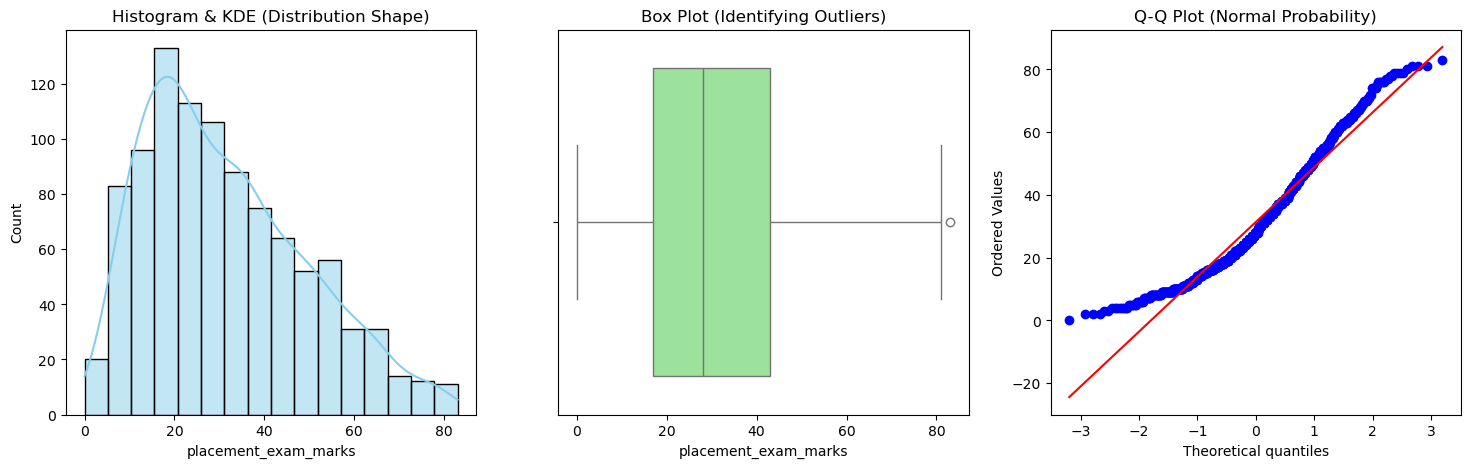

In [30]:
visual_inspection(df_trimmed_2['placement_exam_marks'])

In [22]:
df['test_score_capped'] = df['placement_exam_marks'].clip(lower=lower_limit, upper=upper_limit)
df

,cgpa,placement_exam_marks,placed,z_cgpa,test_score_capped
0,7.19,26.0,1,0.371425,26.0
1,7.46,38.0,1,0.809810,38.0
2,7.54,40.0,1,0.939701,40.0
3,6.42,8.0,1,-0.878782,8.0
4,7.23,17.0,0,0.436371,17.0
...,...,...,...,...,...
995,8.87,44.0,1,3.099150,44.0
996,9.12,65.0,1,3.505062,65.0
997,4.89,34.0,0,-3.362960,34.0
998,8.62,46.0,1,2.693239,46.0
